In [3]:
import warnings
warnings.filterwarnings("ignore")

# Gaussian Mixture Model

GMM modella la distribuzione normale come combinazione di K gaussiane. Rispetto a KDE è più scalabile e può catturare distribuzioni multimodali. Usiamo 3 componenti con covarianza diagonale per evitare instabilità numeriche. La soglia e la metrica di valutazione sono le stesse del KDE.

In [6]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import os
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

with open("preprocessing.pkl", "rb") as f:
    prep = pickle.load(f)

features = prep["features"]
all_files = prep["all_files"]

def train_and_evaluate_gmm(fpath, features, n_components=3):
    df = pd.read_csv(fpath, sep=";")
    df_normal = df[df["anomaly"] == 0]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_normal[features].values)
    
    gmm = GaussianMixture(n_components=n_components, random_state=42, 
                          n_init=5, covariance_type="diag")
    gmm.fit(X_train)
    
    scores_train = gmm.score_samples(X_train)
    threshold = np.percentile(scores_train, 5)
    
    X_all = scaler.transform(df[features].values)
    scores_all = gmm.score_samples(X_all)
    
    first_real = df[df["anomaly"] == 1].index[0]
    detections = np.where(scores_all < threshold)[0]
    detections_after = detections[detections >= first_real]
    
    if len(detections_after) > 0:
        first_detected = detections_after[0]
        delay = first_detected - first_real
    else:
        first_detected = None
        delay = None
    
    return {
        "first_real": first_real,
        "first_detected": first_detected,
        "delay": delay,
        "scores": scores_all,
        "threshold": threshold,
        "df": df
    }

# Tutti i file
results_gmm = []
for fpath in all_files:
    res = train_and_evaluate_gmm(fpath, features)
    folder = fpath.split("/")[-2]
    fname = fpath.split("/")[-1]
    results_gmm.append({
        "file": f"{folder}/{fname}",
        "folder": folder,
        "first_real": res["first_real"],
        "first_detected": res["first_detected"],
        "delay": res["delay"]
    })

df_results_gmm = pd.DataFrame(results_gmm)
print(df_results_gmm[["file", "delay"]])
print(f"\nRitardo medio: {df_results_gmm['delay'].mean():.1f} timestep")
print(f"Non rilevati: {df_results_gmm['delay'].isna().sum()}")

             file  delay
0    valve1/0.csv      1
1    valve1/1.csv      0
2   valve1/10.csv      3
3   valve1/11.csv     42
4   valve1/12.csv      2
5   valve1/13.csv      8
6   valve1/14.csv     25
7   valve1/15.csv      0
8    valve1/2.csv     38
9    valve1/3.csv     38
10   valve1/4.csv      5
11   valve1/5.csv      0
12   valve1/6.csv     46
13   valve1/7.csv      7
14   valve1/8.csv      2
15   valve1/9.csv      4
16   valve2/0.csv      0
17   valve2/1.csv     34
18   valve2/2.csv     18
19   valve2/3.csv     21
20    other/1.csv     11
21   other/10.csv      2
22   other/11.csv      2
23   other/12.csv      1
24   other/13.csv      2
25   other/14.csv      4
26    other/2.csv      0
27    other/3.csv      9
28    other/4.csv      3
29    other/5.csv      0
30    other/6.csv      0
31    other/7.csv      1
32    other/8.csv      1
33    other/9.csv      2

Ritardo medio: 9.8 timestep
Non rilevati: 0


## Score su valve1/1.csv

Verifica visiva del comportamento del modello su un file rappresentativo prima di procedere con la valutazione completa.

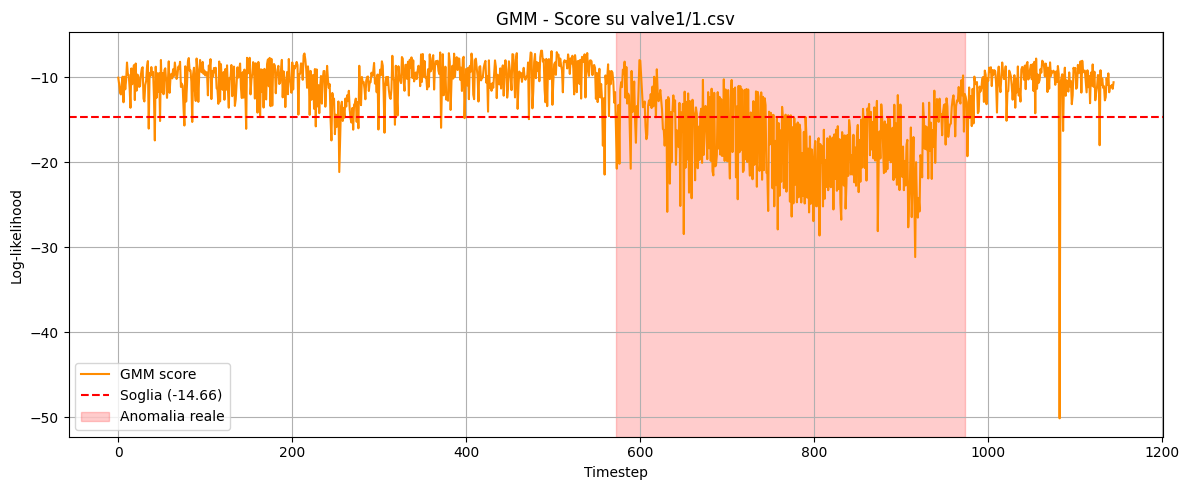

Anomalia inizia al timestep: 572
Prima detezione: 572
Ritardo: 0 timestep


In [7]:
# Visualizzazione su valve1/1.csv
result = train_and_evaluate_gmm(all_files[1], features)

plt.figure(figsize=(12, 5))
plt.plot(result["scores"], color="darkorange", label="GMM score")
plt.axhline(y=result["threshold"], color="red", linestyle="--",
            label=f"Soglia ({result['threshold']:.2f})")
anomaly_idx = result["df"][result["df"]["anomaly"] == 1].index
plt.axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.2, color="red", label="Anomalia reale")
plt.xlabel("Timestep")
plt.ylabel("Log-likelihood")
plt.title("GMM - Score su valve1/1.csv")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Anomalia inizia al timestep: {result['first_real']}")
print(f"Prima detezione: {result['first_detected']}")
print(f"Ritardo: {result['delay']} timestep")

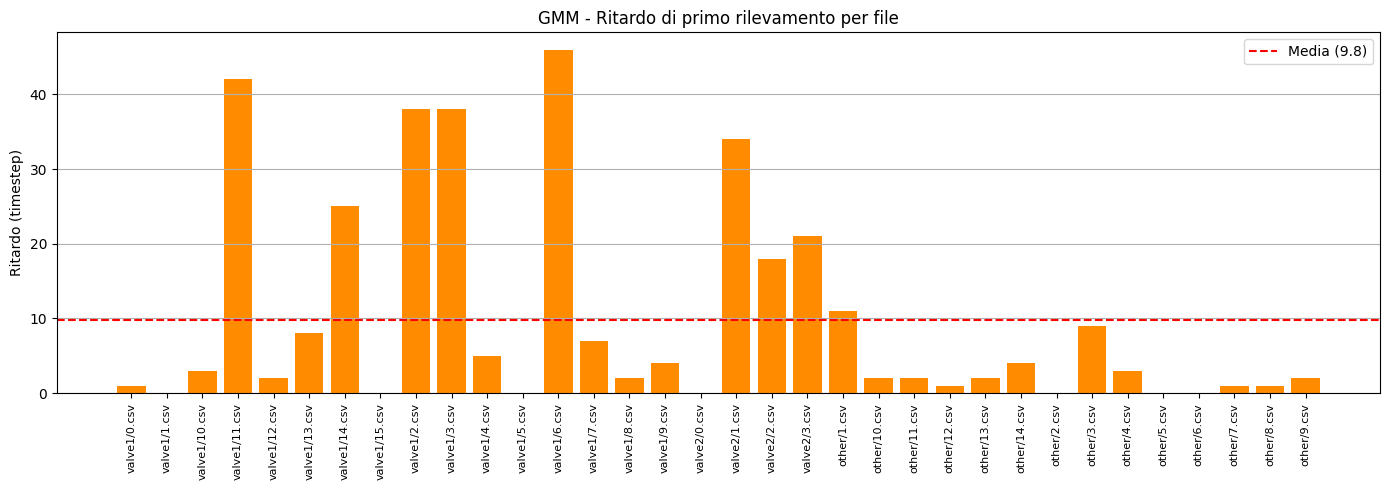

In [5]:
plt.figure(figsize=(14, 5))
plt.bar(df_results_gmm["file"], df_results_gmm["delay"], color="darkorange")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Ritardo (timestep)")
plt.title("GMM - Ritardo di primo rilevamento per file")
plt.axhline(y=df_results_gmm["delay"].mean(), color="red", linestyle="--",
            label=f"Media ({df_results_gmm['delay'].mean():.1f})")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()